In [1]:
import os 
from yaml import safe_load
from munch import munchify
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu, norm
from pre.load import fits2numpy
from pre.preprocess import preprocess

with open(os.getenv("CONFIG_PATH")) as f:
    cfg = munchify(safe_load(f))

In [2]:
# def get_intensities(root_dir: str, cls: int) -> list:
#     intensities = []
#     path = os.path.join(root_dir, str(cls))
#     for file in tqdm(os.listdir(path)):
#         data = fits2numpy(os.path.join(path, file))
#         intensities.append(data.sum())
#     return intensities

In [3]:
# def get_intensities_morph(root_dir: str, files: list[str]) -> list:
#     intensities = []
#     for file in tqdm(files):
#         folder = file.split('_')[0] 
#         data_raw = fits2numpy(os.path.join(root_dir, folder, file))
#         data = preprocess(data_raw)
#         intensities.append(data.sum())
#     return intensities

In [4]:
classification = pd.read_csv("/home/zagorulia/ml/classification_flux_density_ssl.csv", index_col=0)
classification.head()

,file,prob,pred,intensity
0,J1608-1625_S_2018_07_01_pet_map.fits,0.020059,0,0.074893
1,J1608-1625_S_2014_08_09_zb_map.fits,0.002220,0,0.102245
2,J1608-1625_X_2014_08_09_pus_map.fits,0.013989,0,0.067042
3,J1608-1625_X_2017_08_05_pus_map.fits,0.006702,0,0.061133
4,J1608-1625_X_2006_12_18_yyk_map.fits,0.002727,0,0.094756


In [5]:
classification['pred'].value_counts()

pred
0    70543
1    63202
Name: count, dtype: int64

In [6]:
point_sources = classification[classification.prob < 0.5]
jet_sources = classification[classification.prob >= 0.5]
point_sources_ints2 = point_sources.intensity.tolist()
jet_sources_ints2 = jet_sources.intensity.tolist()

In [7]:
# point_sources_ints = get_intensities(cfg.val_path, 0)
# jet_sources_ints = get_intensities(cfg.val_path, 2)

In [8]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# jet_vals = np.array(jet_sources_ints).ravel()
# point_vals = np.array(point_sources_ints).ravel()
# _, bins = np.histogram(point_vals, bins=500)

# ax.hist(point_vals, bins=bins, alpha=0.5, color='blue', label='Point sources')
# ax.hist(jet_vals, bins=bins, alpha=0.5, color='red', label='Jet sources')

# point_median = np.median(np.array(point_sources_ints))
# jet_median = np.median(np.array(jet_sources_ints))
# ax.axvline(point_median, ls='--', color='black', label=f'Point median, {point_median:.1f}')
# ax.axvline(jet_median, ls='-.', color='black', label=f'Jet median, {jet_median:.1f}')
# ax.set_title('Intensity sum')
# # ax.set_xlim(0, 400)
# ax.set_xlabel("Jy/Beam")
# ax.set_xscale('log')
# ax.grid(True)
# ax.legend()

0.1558877507456412 0.4150966989515527


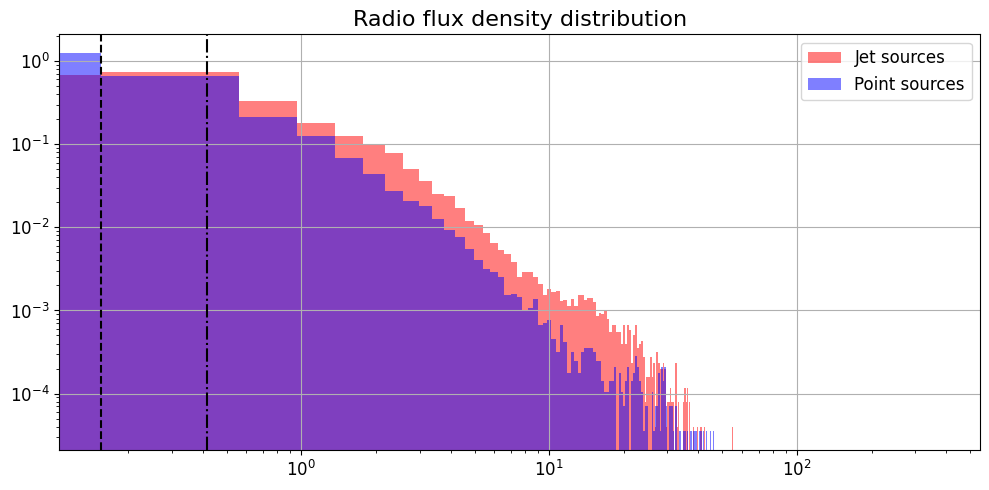

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
jet_vals2 = np.array(jet_sources_ints2).ravel()
point_vals2 = np.array(point_sources_ints2).ravel()
_, bins2 = np.histogram(point_vals2, bins=1000)

ax.hist(jet_vals2, bins=bins2, alpha=0.5, color='red', label='Jet sources', density=True)
ax.hist(point_vals2, bins=bins2, alpha=0.5, color='blue', label='Point sources', density=True)


point_median2 = np.median(np.array(point_sources_ints2))
jet_median2 = np.median(np.array(jet_sources_ints2))
ax.axvline(point_median2, ls='--', color='black') # label=f'Point median, {point_median2:.1f}'
ax.axvline(jet_median2, ls='-.', color='black') # label=f'Jet median, {jet_median2:.1f}'
ax.set_title('Radio flux density distribution', fontsize=16)
# ax.set_xlim(0, 100)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlabel("Radio flux density [Jy]")
# ax.set_ylabel("Source count")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.grid(True)
ax.legend(fontsize=12)
plt.tight_layout()
print(point_median2, jet_median2)

In [10]:
def dominance_stats(A, B):
    # one-sided MWU: H1: A > B
    U, p = mannwhitneyu(A, B, alternative="greater")

    n1, n2 = len(A), len(B)

    # Cliff's delta
    delta = (2*U)/(n1*n2) - 1

    # dominance probability
    P = (U)/(n1*n2)
    mean = n1*n2/2
    var  = n1*n2*(n1+n2+1)/12
    z = (U - mean) / np.sqrt(var)

    # log10(p) without underflow
    log10_p = np.log10(2) + (norm.logsf(abs(z)) / np.log(10))

    print("−log10(p) =", -log10_p)

    return {
        "p_value": p,
        "P(A > B)": P,
        "Cliffs_delta": delta
    }

In [11]:
# dominance_stats(jet_sources_ints, point_sources_ints)

In [12]:
dominance_stats(jet_sources_ints2, point_sources_ints2)

−log10(p) = 2212.511968705321


{'p_value': np.float64(0.0),
 'P(A > B)': np.float64(0.6595205601508181),
 'Cliffs_delta': np.float64(0.3190411203016361)}

In [13]:
# from astropy.io import fits
# file = "J1608-1625/J1608-1625_S_2018_07_01_pet_map.fits"

# for folder in tqdm(os.listdir(cfg.fits_path)):
#     for file in os.listdir(os.path.join(cfg.fits_path, folder)):
#         if file.endswith("maps.fits"):
#             h = fits.getheader(os.path.join(cfg.fits_path, folder, file))
#             if h.get("BUNIT") != "JY/BEAM":
#                 print(file)